<a href="https://colab.research.google.com/github/JorgeEncinas/pytorch_ztm/blob/main/extras/exercises/02_pytorch_classification_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02. PyTorch Classification Exercises

The following is a template for 02. PyTorch Classification exercises.

It's only starter code and it's your job to fill in the blanks.

Because of the flexibility of PyTorch, there may be more than one way to answer the question.

Don't worry about trying to be *right* just try writing code that suffices the question.

## Resources
* These exercises are based on [notebook 02 of the learn PyTorch course](https://www.learnpytorch.io/02_pytorch_classification/).
* You can see one form of [solutions on GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions) (but try the exercises below yourself first!).

In [1]:
# Import torch
import torch

# Setup device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Setup random seed
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)

## 1. Make a binary classification dataset with Scikit-Learn's [`make_moons()`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html) function.
  * For consistency, the dataset should have 1000 samples and a `random_state=42`.
  * Turn the data into PyTorch tensors.
  * Split the data into training and test sets using `train_test_split` with 80% training and 20% testing.

In [14]:
# Create a dataset with Scikit-Learn's make_moons()
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(
    n_samples=1000,
    shuffle=True,
    noise=0.08,
    random_state=RANDOM_SEED
)

len(X_moons), len(y_moons), X_moons.dtype, y_moons.dtype

(1000, 1000, dtype('float64'), dtype('int64'))

In [15]:
# Turn data into a DataFrame
import pandas as pd

moons_dataset = pd.DataFrame({
    "X_1": X_moons[:, 0],
    "X_2": X_moons[:, 1],
    "y": y_moons
})

moons_dataset

,X_1,X_2,y
0,-0.039430,0.428994,1
1,1.009890,-0.435174,1
2,0.882359,-0.303504,1
3,0.324256,-0.428016,1
4,-0.836834,0.533269,0
...,...,...,...
995,0.805610,0.545558,0
996,-0.155564,0.928527,0
997,1.675589,-0.332101,1
998,-0.957744,0.289361,0


Text(0.5, 1.0, "Sci-kit Learn's `make_moons`")

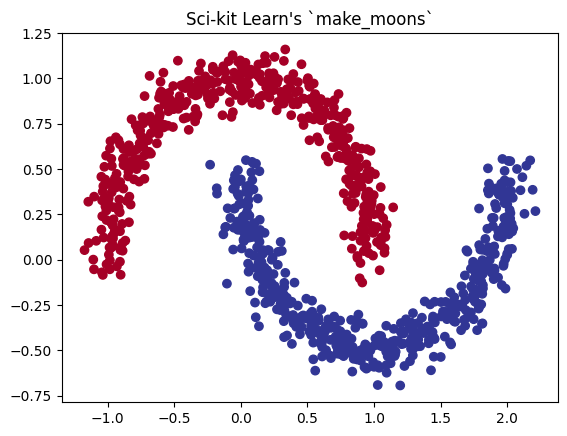

In [16]:
# Visualize the data on a scatter plot
import matplotlib.pyplot as plt

plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap=plt.cm.RdYlBu)
plt.title("Sci-kit Learn's `make_moons`")

In [17]:
# Turn data into tensors of dtype float
X_moons, y_moons = torch.from_numpy(X_moons).type(torch.float), torch.from_numpy(y_moons).type(torch.float)

# Split the data into train and test sets (80% train, 20% test)
from sklearn.model_selection import train_test_split

Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_moons, y_moons,
    test_size=0.2, random_state=RANDOM_SEED,
)

len(Xm_train), len(ym_train), len(Xm_test), len(ym_test), X_moons.dtype, y_moons.dtype

(800, 800, 200, 200, torch.float32, torch.float32)

## 2. Build a model by subclassing `nn.Module` that incorporates non-linear activation functions and is capable of fitting the data you created in 1.
  * Feel free to use any combination of PyTorch layers (linear and non-linear) you want.

In [18]:
import torch
from torch import nn

# Inherit from nn.Module to make a model capable of fitting the mooon data
class MoonModelV0(nn.Module):
    ## Your code here ##
    def __init__(self):
      super().__init__()
      self.graph = nn.Sequential(
          nn.Linear(in_features=2, out_features=8),
          nn.ReLU(),
          nn.Linear(in_features=8, out_features=16),
          nn.ReLU(),
          nn.Linear(in_features=16, out_features=8),
          nn.ReLU(),
          nn.Linear(in_features=8, out_features=1) #Just one class at the very end!
      )

    def forward(self, x):
        ## Your code here ##
        return self.graph(x)

# Instantiate the model
## Your code here ##
model_0 = MoonModelV0()

## 3. Setup a binary classification compatible loss function and optimizer to use when training the model built in 2.

In [19]:
# Setup loss function
loss_fn = nn.BCEWithLogitsLoss()

# Setup optimizer to optimize model's parameters
optimizer = torch.optim.Adam(
    params=model_0.parameters(),
    lr=0.01
)

## 4. Create a training and testing loop to fit the model you created in 2 to the data you created in 1.
  * Do a forward pass of the model to see what's coming out in the form of logits, prediction probabilities and labels.
  * To measure model accuray, you can create your own accuracy function or use the accuracy function in [TorchMetrics](https://torchmetrics.readthedocs.io/en/latest/).
  * Train the model for long enough for it to reach over 96% accuracy.
  * The training loop should output progress every 10 epochs of the model's training and test set loss and accuracy.

In [21]:
# What's coming out of our model?

# logits (raw outputs of model)
print("Logits:")
## Your code here ##
y_logits = model_0(Xm_train)
print(y_logits[:5])

# Prediction probabilities
print("Pred probs:")
## Your code here ##
y_pred_probs = torch.sigmoid(y_logits)
print(y_pred_probs[:5])

# Prediction labels
print("Pred labels:")
## Your code here ##
y_preds = torch.round(y_pred_probs)
print(y_preds[:5])

Logits:
tensor([[-0.2238],
        [-0.3097],
        [-0.2937],
        [-0.2921],
        [-0.2925]], grad_fn=<SliceBackward0>)
Pred probs:
tensor([[0.4443],
        [0.4232],
        [0.4271],
        [0.4275],
        [0.4274]], grad_fn=<SliceBackward0>)
Pred labels:
tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.]], grad_fn=<SliceBackward0>)


In [22]:
# Let's calculuate the accuracy using accuracy from TorchMetrics
!pip -q install torchmetrics # Colab doesn't come with torchmetrics
from torchmetrics import Accuracy

## TODO: Uncomment this code to use the Accuracy function
acc_fn = Accuracy(task="multiclass", num_classes=2).to(device) # send accuracy function to device
acc_fn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.6/962.6 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 116.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 94.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 87.8 MB/s eta 0:00:00


MulticlassAccuracy()

In [25]:
## TODO: Uncomment this to set the seed
torch.manual_seed(RANDOM_SEED)

# Setup epochs
epochs = 500

# Send data to the device
model_0 = model_0.to(device)
Xm_train = Xm_train.to(device)
ym_train = ym_train.to(device)
Xm_test = Xm_test.to(device)
ym_test = ym_test.to(device)

for epoch in range(epochs):
  model_0.train()

  y_logits = model_0(Xm_train).squeeze()
  y_pred_probs = torch.sigmoid(y_logits)
  y_preds = torch.round(y_pred_probs)

  # 2. Calculate the loss
  # loss = loss_fn(y_logits, y_train) # loss = compare model raw outputs to desired model outputs
  loss = loss_fn(y_logits, ym_train)
  # Calculate the accuracy
  # acc = acc_fn(y_pred, y_train.int()) # the accuracy function needs to compare pred labels (not logits) with actual labels
  acc = acc_fn(y_preds.int(), ym_train.int())

  # 3. Zero the gradients
  optimizer.zero_grad()

  # 4. Loss backward (perform backpropagation) - https://brilliant.org/wiki/backpropagation/#:~:text=Backpropagation%2C%20short%20for%20%22backward%20propagation,to%20the%20neural%20network's%20weights.
  loss.backward()
  # 5. Step the optimizer (gradient descent) - https://towardsdatascience.com/gradient-descent-algorithm-a-deep-dive-cf04e8115f21#:~:text=Gradient%20descent%20(GD)%20is%20an,e.g.%20in%20a%20linear%20regression)
  optimizer.step()

  if epoch % 10 == 0:
    model_0.eval()
    with torch.inference_mode():
      y_test_logits = model_0(Xm_test).squeeze()
      y_test_pred_probs = torch.sigmoid(y_test_logits)
      y_test_preds = torch.round(y_test_pred_probs)
    test_loss = loss_fn(y_test_logits, ym_test)
    test_acc = acc_fn(y_test_preds.int(), ym_test.int())

    print(f"Epoch: {epoch} | Loss: {loss} | Acc: {acc} \n TestLoss: {test_loss} | TestAcc: {test_acc}")
  # Print out what's happening every 100 epochs
  # if epoch % 100 == 0:


Epoch: 0 | Loss: 0.699257493019104 | Acc: 0.5 
 TestLoss: 0.6937367916107178 | TestAcc: 0.5
Epoch: 10 | Loss: 0.590469479560852 | Acc: 0.7487499713897705 
 TestLoss: 0.5926761627197266 | TestAcc: 0.7049999833106995
Epoch: 20 | Loss: 0.4203576147556305 | Acc: 0.8125 
 TestLoss: 0.422250360250473 | TestAcc: 0.7900000214576721
Epoch: 30 | Loss: 0.29686880111694336 | Acc: 0.8600000143051147 
 TestLoss: 0.2888866364955902 | TestAcc: 0.8600000143051147
Epoch: 40 | Loss: 0.24333399534225464 | Acc: 0.8712499737739563 
 TestLoss: 0.2291191816329956 | TestAcc: 0.8949999809265137
Epoch: 50 | Loss: 0.22457139194011688 | Acc: 0.8824999928474426 
 TestLoss: 0.20663835108280182 | TestAcc: 0.9100000262260437
Epoch: 60 | Loss: 0.20946361124515533 | Acc: 0.8837500214576721 
 TestLoss: 0.19408056139945984 | TestAcc: 0.9200000166893005
Epoch: 70 | Loss: 0.18829967081546783 | Acc: 0.9150000214576721 
 TestLoss: 0.17175708711147308 | TestAcc: 0.9449999928474426
Epoch: 80 | Loss: 0.1392953097820282 | Acc: 0.

## 5. Make predictions with your trained model and plot them using the `plot_decision_boundary()` function created in this notebook.

In [25]:
# Plot the model predictions
import numpy as np

def plot_decision_boundary(model, X, y):

    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Source - https://madewithml.com/courses/foundations/neural-networks/
    # (with modifications)
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101),
                         np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits)) # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

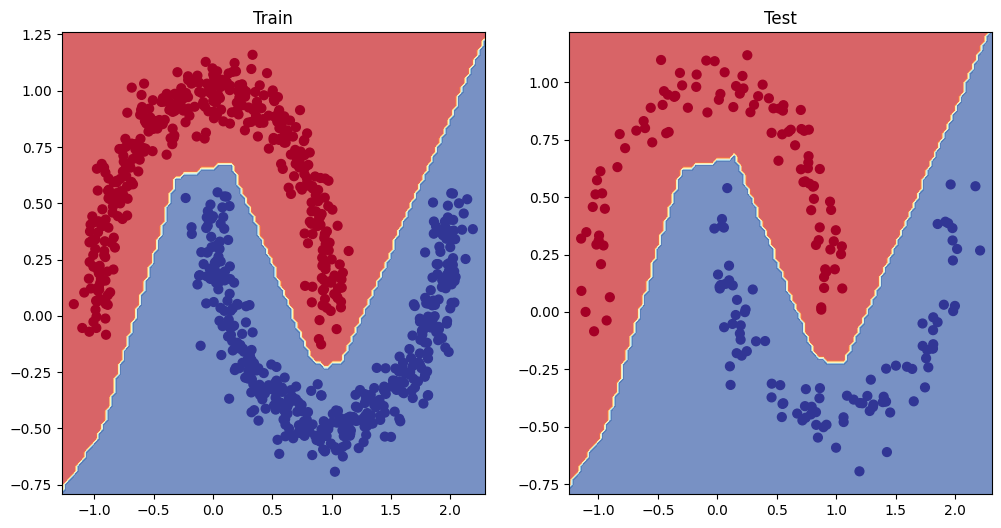

In [30]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model=model_0, X=Xm_train, y=ym_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model=model_0, X=Xm_test, y=ym_test)

## 6. Replicate the Tanh (hyperbolic tangent) activation function in pure PyTorch.
  * Feel free to reference the [ML cheatsheet website](https://ml-cheatsheet.readthedocs.io/en/latest/activation_functions.html#tanh) for the formula.

Text(0.5, 1.0, 'A Straight Line')

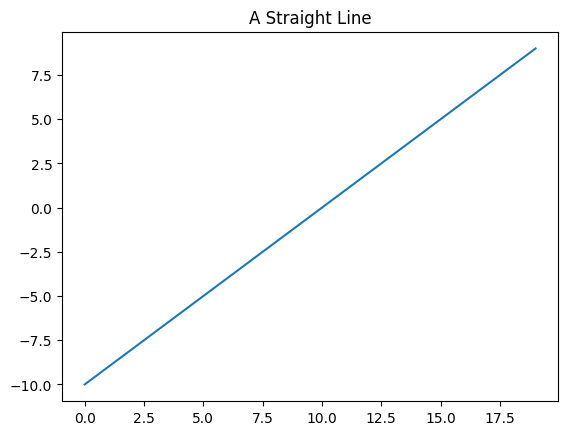

In [32]:
# Create a straight line tensor
straight_line_tensor = torch.arange(start=-10, end=10, step=1.)
plt.plot(straight_line_tensor)
plt.title("A Straight Line")

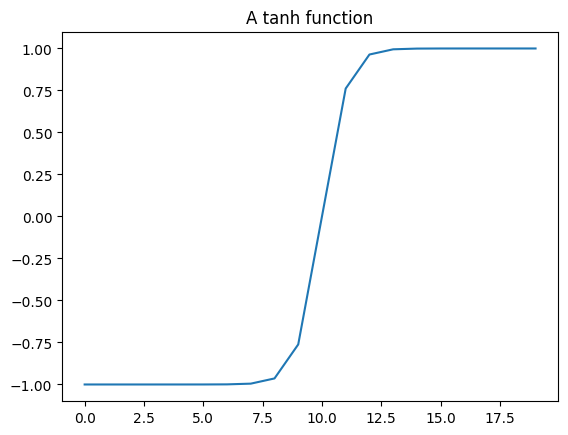

In [33]:
# Test torch.tanh() on the tensor and plot it
tanhtensor = torch.tanh(straight_line_tensor)
plt.title("A tanh function")
plt.plot(tanhtensor)

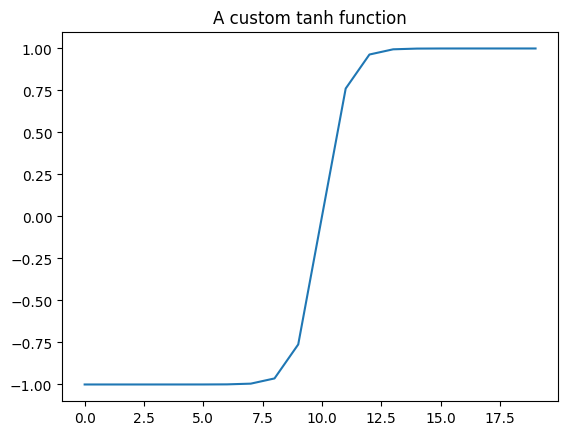

In [34]:
# Replicate torch.tanh() and plot it
def tanh(x : torch.Tensor) -> torch.Tensor:
  return (torch.exp(x) - torch.exp(-x)) / (torch.exp(x) + torch.exp(-x))

custom_tanh_tensor = tanh(straight_line_tensor)
plt.title("A custom tanh function")
plt.plot(custom_tanh_tensor)

## 7. Create a multi-class dataset using the [spirals data creation function from CS231n](https://cs231n.github.io/neural-networks-case-study/) (see below for the code).
  * Split the data into training and test sets (80% train, 20% test) as well as turn it into PyTorch tensors.
  * Construct a model capable of fitting the data (you may need a combination of linear and non-linear layers).
  * Build a loss function and optimizer capable of handling multi-class data (optional extension: use the Adam optimizer instead of SGD, you may have to experiment with different values of the learning rate to get it working).
  * Make a training and testing loop for the multi-class data and train a model on it to reach over 95% testing accuracy (you can use any accuracy measuring function here that you like) - 1000 epochs should be plenty.
  * Plot the decision boundaries on the spirals dataset from your model predictions, the `plot_decision_boundary()` function should work for this dataset too.

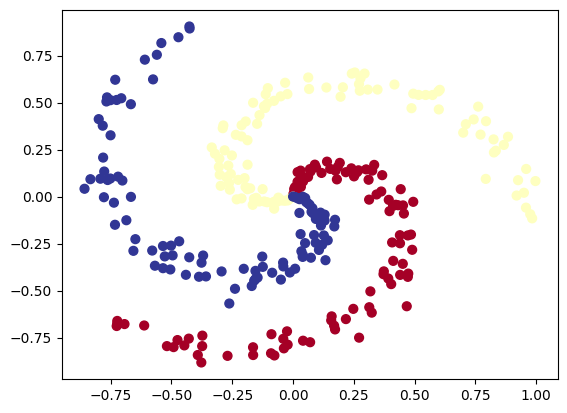

In [5]:
# Code for creating a spiral dataset from CS231n
import numpy as np
import matplotlib.pyplot as plt
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
plt.show()

In [6]:
# Turn data into tensors
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
X = torch.from_numpy(X).type(torch.float) # features as float32
y = torch.from_numpy(y).type(torch.LongTensor) # labels need to be of type long

# Create train and test splits
from sklearn.model_selection import train_test_split
Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

In [7]:
# Let's calculuate the accuracy for when we fit our model
!pip -q install torchmetrics # colab doesn't come with torchmetrics
from torchmetrics import Accuracy

## TODO: uncomment the two lines below to send the accuracy function to the device
acc_fn = Accuracy(task="multiclass", num_classes=4).to(device)
acc_fn

MulticlassAccuracy()

In [20]:
from torch import nn

# Create model by subclassing nn.Module
class MultiClassClassifierV0(nn.Module):
  def __init__(self):
    super().__init__()

    self.graph = nn.Sequential(
        nn.Linear(in_features=2, out_features=8),
        nn.ReLU(),
        nn.Linear(in_features=8, out_features=16),
        nn.ReLU(),
        nn.Linear(in_features=16, out_features=8),
        nn.ReLU(),
        nn.Linear(in_features=8, out_features=3) # There are 3 different classes.
    )

  def forward(self, x):
    return self.graph(x)

# Instantiate model and send it to device
model_1 = MultiClassClassifierV0()

In [21]:
# Setup data to be device agnostic
model_1 = model_1.to(device)
Xs_train, ys_train = Xs_train.to(device), ys_train.to(device)
Xs_test, ys_test = Xs_test.to(device), ys_test.to(device)

# Print out first 10 untrained model outputs (forward pass)
print("Logits:")
## Your code here ##
with torch.inference_mode():
  y_logits = model_1(Xs_train)
print(y_logits[:5])

print("Pred probs:")
## Your code here ##
y_pred_probs = torch.softmax(y_logits, dim=1)
print(y_pred_probs[:5])

print("Pred labels:")
## Your code here ##
y_preds = torch.argmax(y_pred_probs, dim=1)
print(y_preds[:5])

Logits:
tensor([[-0.0718,  0.3319,  0.3370],
        [-0.0622,  0.3263,  0.3330],
        [-0.0662,  0.3219,  0.3388],
        [-0.0277,  0.2954,  0.3267],
        [-0.0268,  0.2924,  0.3253]], device='cuda:0')
Pred probs:
tensor([[0.2499, 0.3741, 0.3760],
        [0.2526, 0.3725, 0.3750],
        [0.2517, 0.3710, 0.3773],
        [0.2627, 0.3629, 0.3744],
        [0.2633, 0.3623, 0.3744]], device='cuda:0')
Pred labels:
tensor([2, 2, 2, 2, 2], device='cuda:0')


In [22]:
Xs_train.dtype, ys_train.dtype, Xs_test.dtype, ys_test.dtype

(torch.float32, torch.int64, torch.float32, torch.int64)

In [23]:
# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    params=model_1.parameters(),
    lr=0.01
)

In [24]:
# Build a training loop for the model
epochs = 1000


# Loop over data
for epoch in range(epochs):

  ## Training
  model_1.train()

  # 1. Forward pass
  y_logits = model_1(Xs_train).squeeze()
  y_pred_probs = torch.softmax(y_logits, dim=1)
  y_preds = torch.argmax(y_pred_probs, dim=1)

  # 2. Calculate the loss
  loss = loss_fn(y_logits, ys_train) #Input expects unnormalized logits
  acc = acc_fn(y_preds, ys_train)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward
  loss.backward()

  # 5. Optimizer step
  optimizer.step()

  ## Testing
  if epoch % 100 == 0:
    model_1.eval()

    # 1. Forward pass
    y_test_logits = model_1(Xs_test).squeeze()
    y_test_pred_probs = torch.softmax(y_test_logits, dim=1)
    y_test_preds = torch.argmax(y_test_pred_probs, dim=1)

    # 2. Caculate loss and acc
    test_loss = loss_fn(y_test_logits, ys_test)
    test_acc = acc_fn(y_test_preds, ys_test)

    # Print out what's happening every 100 epochs
    print(f"Epoch: {epoch} | Loss: {loss} | Acc: {acc} \n Test Loss: {test_loss} | Test Acc: {test_acc}")


Epoch: 0 | Loss: 1.1157845258712769 | Acc: 0.25 
 Test Loss: 1.1235851049423218 | Test Acc: 0.36666667461395264
Epoch: 100 | Loss: 0.10531453788280487 | Acc: 0.9708333611488342 
 Test Loss: 0.07745461165904999 | Test Acc: 1.0
Epoch: 200 | Loss: 0.029095616191625595 | Acc: 0.9916666746139526 
 Test Loss: 0.004145490005612373 | Test Acc: 1.0
Epoch: 300 | Loss: 0.020948214456439018 | Acc: 0.9916666746139526 
 Test Loss: 0.0005675203283317387 | Test Acc: 1.0
Epoch: 400 | Loss: 0.01793512888252735 | Acc: 0.9916666746139526 
 Test Loss: 0.0001391377445543185 | Test Acc: 1.0
Epoch: 500 | Loss: 0.01634945534169674 | Acc: 0.9916666746139526 
 Test Loss: 6.751717592123896e-05 | Test Acc: 1.0
Epoch: 600 | Loss: 0.015492257662117481 | Acc: 0.9916666746139526 
 Test Loss: 4.3056777940364555e-05 | Test Acc: 1.0
Epoch: 700 | Loss: 0.014964843168854713 | Acc: 0.9916666746139526 
 Test Loss: 3.43189385603182e-05 | Test Acc: 1.0
Epoch: 800 | Loss: 0.014836284331977367 | Acc: 0.9916666746139526 
 Test Lo

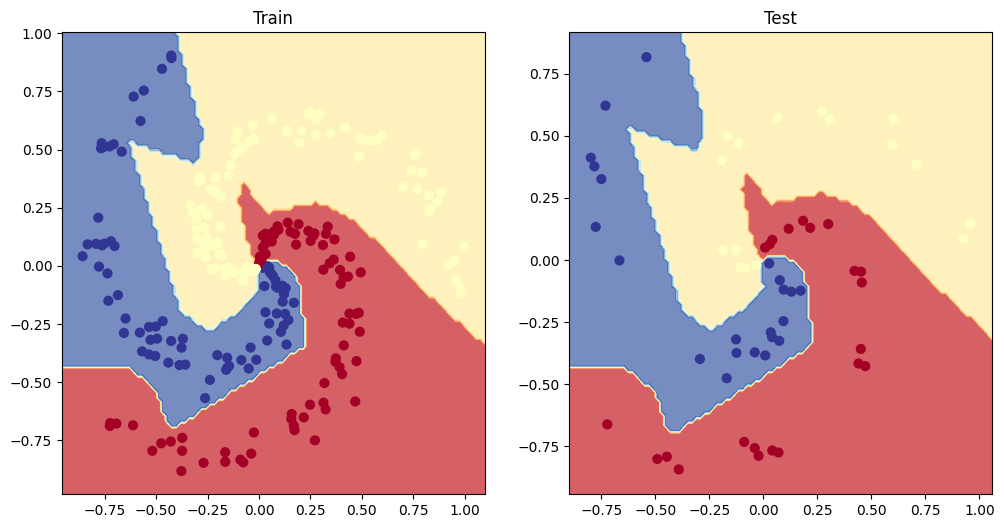

In [26]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model=model_1, X=Xs_train, y=ys_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model=model_1, X=Xs_test, y=ys_test)

### Extra-curriculum

* 3 problems where Machine Classification could be useful, try being creative.
  - Detecting ripe from unripe fruit
  - Spam / Non-spam
  - Detect different animal types and different breeds
  - For something more out there...
    - Maybe we can identify different handwritings
    - Or different languages from text or speech
    - How about detecting human emotion, would that be a classification problem?

* Momentum in Gradient-based optimizers like sGD or Adam
  - My best understanding of it (without reading anything again) is that Momentum is the concept that whenever we keep moving in the same direction in consecutive iterations, we start taking bigger steps in that direction, analogous to a ball rolling down a hill, whereas less consistent directions would not have this phenomenon. Think of a ball rolling down a hill, but there are slight movements to one side and then another as it goes down an uneven hill.
  - So this idea of calling it 'momentum' seems very grounded in a physics intuition.

* When is accuracy a poor metric to use?
  - Comes from [this article](https://willkoehrsen.github.io/statistics/learning/beyond-accuracy-precision-and-recall/)
  - When there is a huge class imbalance. The article included mentions that for example, looking for a rare occurrence when the other class is the norm for 99% of the cases, then you can have a 99% accurate classifier by just saying everything is the predominant class.
  -Use RECALL: The ability of the model to find all the relevant cases within a dataset.
  - Recall: TP / (TP + FN)


You can think of Recall as finding all the data points of interest in a dataset.

Now there is another issue; if we now only use Recall, and classify everything as positive, our Recall is 1.0

That means we must not consider Recall alone. We can also consider Precision alongside it.

- Precision = TP / (TP + FP)

As you can see, this one takes into account False Positives, which would stop you from classifying everything as positive.

- Recall: Ability to find all Relevant Instances in a Model
- Precision: Proportion of the data points that were ACTUALLY RELEVANT, from ALL of the ones it pointed to as relevant.

### Precision - Recall trade-off

Looking back then:
- Our first model has excellent accuracy (99%!), but 0 precision, and 0 recall, since there are no True Positives (it always predicts Negative)
- Suppose now we create a model that only identifies correctly a single person as positive (so it always says negative to everything else but that person)
  - Said model would have a Precision of 1.0, since there are no False Positives
  - However, it would have a low Recall, due to many False Negatives
- Now suppose we go to the other end, and classify EVERYONE as positive. We correctly classify as Positive every single person that should be positive, but we would have many False Positives
  - Our Recall is 1.0, we caught everyone.
  - Our Precision is very low, since we have many False Positives.

That is the Precision-Recall trade-off

## F-1 Score

We might sometimes want to prioritize Recall or Precision, at the expense of the other of the two.

For preliminary disease screening of patients for follow-up examinations, we would want a Recall of 1.0
  - That is, we want to find ALL patients who actually have the disease!
  - We can accept a lower precision if the cost of the follow-up examination is not significant.

In cases where we want a "optimal blend" of Precision and Recall we can combine them using the F1 Score, which is the **Harmonic Mean** of Precision and Recall, taking both metrics into account

- F_1 = 2 * (Precision * Recall) / (Precision + Recall)

### Why the Harmonic Mean, and not an Average?

A Harmonic Mean punishes extreme values!

A precision of 1.0, and recall of 0.0, would have an average of 0.5, but an F1 Score of 0.

The F1 Score gives EQUAL WEIGHT to both measures, and is a specific example of the F_beta metric, where beta can be adjusted to give more weight to either recall or precision.

For example, another metric that combines Precision and Recall is the **Geometric Mean of Precision and Recall**, but the F1 Score is the most commonly used.

## Receiver Operating Characteristic (ROC) curve
A visualization technique for showing the performance of a classification model.

It shows how the Recall vs Precision relationship CHANGES as we vary the threshold for identifying a POSITIVE in our model.

The ROC Curve plots two things:
- The True Positive Rate (TPR), the Recall.
  - TP / (TP + FN)
- The False Positive Rate (FPR), the probability of false alarm
  - FP / (FP + TN)

"The threshold represents the value above which a data point is considered in the Positive Class.

If we have a model for identifying a disease, our model might output a score for each patient between 0 and 1,

and we can set a threshold in this range for labeling a patient as having the disease (a positive label).

By altering the threshold, we can try to achieve the right Precision-Recall balance".

## Area Under the (ROC) Curve (AUC)
We can quantify a model's ROC Curve by calculating the total Area Under the Curve (AUC).

It is a metric which falls between 0 and 1, with a higher number indicating better classification performance.